In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- Factor de escala real ---
corriente_nA = 1.0 
tiempo_s = 1      # Ajustar
n_total = (corriente_nA * 1e-9 / 1.602177e-19) * tiempo_s # Ntot= (I/e).t use I=Q/t

In [5]:
#DOSIS VS Z
archivo = "bragg_pouch_zcilindJesus.out"

z = []
dose = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()

        if len(parts) != 4:
            continue

        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue

        z.append((z1 + z2) / 2)
        dose.append(d)

plt.figure(figsize=(7,5))
#plt.xlim(-0.15, 0.4)
plt.axvline(x=0.115, color='r', linestyle='--')
plt.axvline(x=0.315, color='r', linestyle='--')
plt.axvline(x=-0.115, color='g', linestyle='--')
plt.axvline(x=0.115, color='b', linestyle='--')

plt.axvspan(-0.115, 0.115, color='g', alpha=0.2, label='acrilico')
plt.axvspan(0.115, 0.315, color='r', alpha=0.2, label='pouch')

plt.legend()
plt.plot(z, dose)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy/source)") # gray por particula simulada (u)
plt.title("Bragg peak")
plt.grid(True)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'bragg_pouch_zcilindJesus.out'

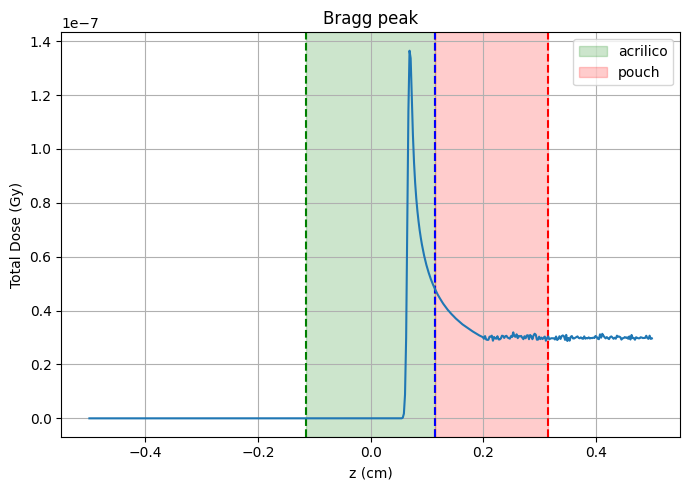

In [7]:
#DOSIS TOTAL VS Z

plt.figure(figsize=(7,5))
#plt.xlim(-0.15, 0.4)
plt.axvline(x=0.115, color='r', linestyle='--')
plt.axvline(x=0.315, color='r', linestyle='--')
plt.axvline(x=-0.115, color='g', linestyle='--')
plt.axvline(x=0.115, color='b', linestyle='--')

plt.axvspan(-0.115, 0.115, color='g', alpha=0.2, label='acrilico')
plt.axvspan(0.115, 0.315, color='r', alpha=0.2, label='pouch')

plt.legend()
plt.plot(z, np.array(dose)*corriente_nA * 1e-9)
plt.xlabel("z (cm)")
plt.ylabel("Total Dose (Gy)") # gray (u)
plt.title("Bragg peak")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
i = np.argmax(dose)

z_max = z[i]
dose_max = dose[i]

print("z del pico:", z_max)
print("dosis máxima:", dose_max)

z del pico: 0.183
dosis máxima: 174.98


In [ ]:
z_np = np.array(z)
dose_np = np.array(dose*n_total)

# Límites del pouch
z_min_pouch = 0.115
z_max_pouch = 0.315

mascara = (z_np >= z_min_pouch) & (z_np <= z_max_pouch)# Puntos dentro del pouch
dosis_promedio = np.mean(dose_np[mascara]) # Promedio de la dosis en esa región

print(f"--- Resultados del Promedio en la Mesh ---")
print(f"Rango analizado: {z_min_pouch} cm a {z_max_pouch} cm")
print(f"Dosis promedio en el Pouch: {dosis_promedio:.5e} Gy")

# El valor máximo (pico) en esa zona:
dosis_max_pouch = np.max(dose_np[mascara])
z_pico_pouch = z_np[mascara][np.argmax(dose_np[mascara])]
print(f"Dosis máxima (Pico de Bragg) detectada en el Pouch: {dosis_max_pouch:.5e} Gy en z = {z_pico_pouch:.4f} cm")

--- Resultados del Promedio en la Mesh ---
Rango analizado: 0.115 cm a 0.315 cm
Dosis promedio en el Pouch: 5.23350e-09 Gy/source
Dosis máxima (Pico de Bragg) detectada en el Pouch: 1.95820e-08 Gy/source en z = 0.2310 cm
